# Exploratory Data Analysis – Adult Income Dataset

This notebook performs a simple Exploratory Data Analysis (EDA) on the Adult Income dataset.

The main objective is to understand:
- The structure and quality of the dataset.
- The distribution of income classes.
- The relationship between income and important demographic and work-related features.
- Basic statistical patterns before building the machine learning model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Final_NB_Data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (32561, 21)


,Age,WorkClass,FNLWGT,Education,EducationNum,MartialStatus,Occupation,Relationship,Race,Sex,...,CapitalLoss,HoursPerWeek,NativeCountry,Label,Age Group,Hours Group,Capital Gain Status,Capital Loss Status,Clean Label,Income Category
0,49.0,Private,193366.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,40.0,United-States,<=50K,46-55,Full-Time,No Capital Gain,No Capital Loss,<=50K,Low Income
1,36.0,Private,155537.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,40.0,United-States,<=50K,36-45,Full-Time,No Capital Gain,No Capital Loss,<=50K,Low Income
2,28.0,Private,92262.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,40.0,United-States,<=50K,26-35,Full-Time,No Capital Gain,No Capital Loss,<=50K,Low Income
3,59.0,Private,199713.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,40.0,United-States,<=50K,56+,Full-Time,No Capital Gain,No Capital Loss,<=50K,Low Income
4,60.0,Private,199378.0,HS-grad,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,40.0,United-States,<=50K,56+,Full-Time,No Capital Gain,No Capital Loss,<=50K,Low Income


## 1. Dataset Overview

First, we inspect the dataset structure, data types, and basic information about the available features.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  32560 non-null  float64
 1   WorkClass            32560 non-null  object 
 2   FNLWGT               32560 non-null  float64
 3   Education            32560 non-null  object 
 4   EducationNum         32560 non-null  float64
 5   MartialStatus        32560 non-null  object 
 6   Occupation           32560 non-null  object 
 7   Relationship         32560 non-null  object 
 8   Race                 32560 non-null  object 
 9   Sex                  32560 non-null  object 
 10  CapitalGain          32560 non-null  float64
 11  CapitalLoss          32560 non-null  float64
 12  HoursPerWeek         32560 non-null  float64
 13  NativeCountry        32560 non-null  object 
 14  Label                32560 non-null  object 
 15  Age Group            32561 non-null 

## 2. Target Variable Analysis

The target variable is `Label`, which represents whether an individual earns more than $50K per year.

- `<=50K` → Lower income
- `>50K` → Higher income

In [ ]:
income_counts = df["Label"].value_counts()

print(income_counts)

Label
<=50K    24719
>50K      7841
Name: count, dtype: int64


In [ ]:
income_percentage = df["Label"].value_counts(normalize=True) * 100

print(income_percentage.round(2))

Label
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


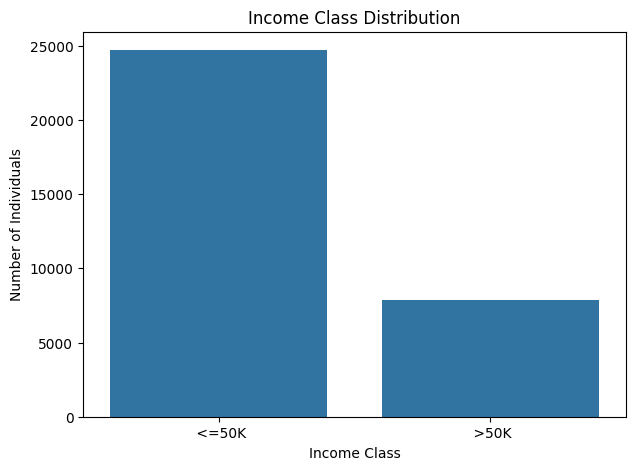

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Label")

plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Number of Individuals")
plt.show()

### Insight

The dataset contains more individuals in the `<=50K` income class than in the `>50K` class.

This indicates that the target variable is imbalanced, which should be considered when evaluating the machine learning model.

## 3. Numerical Features

We examine the main numerical variables to understand their distributions and identify potential patterns.

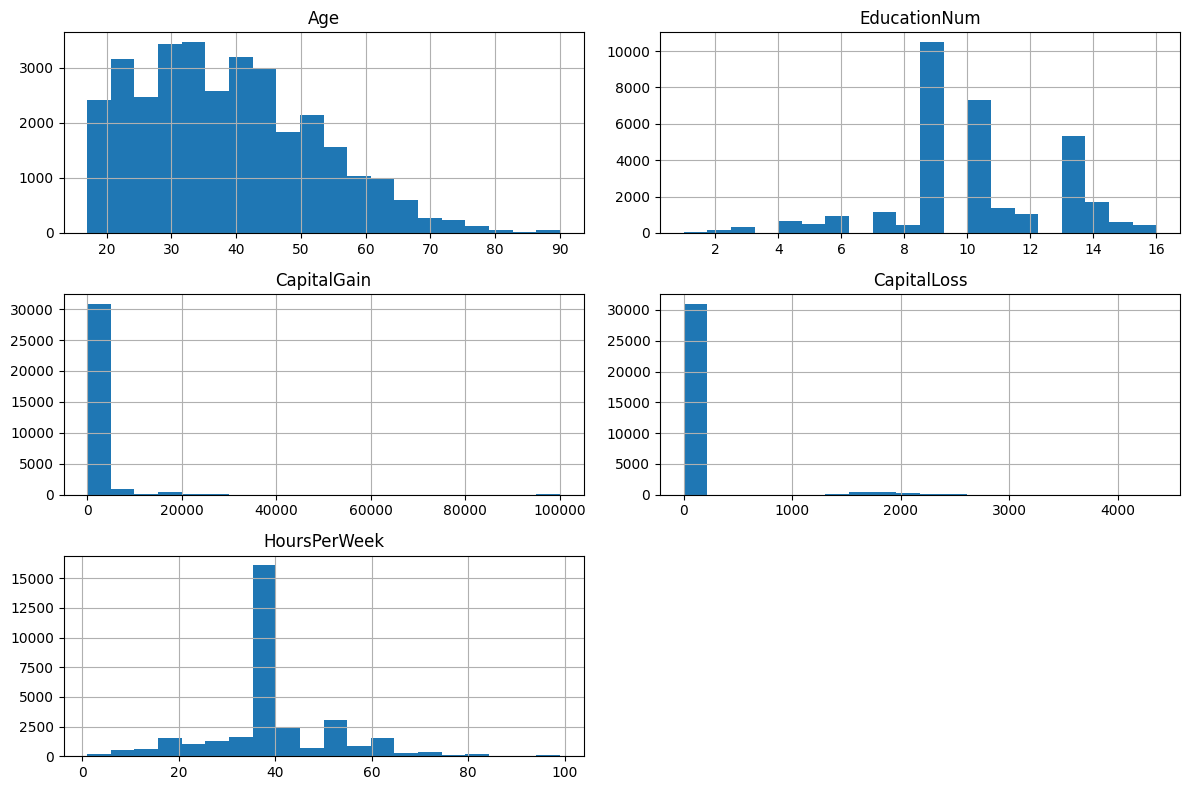

In [ ]:
numeric_columns = [
    "Age",
    "EducationNum",
    "CapitalGain",
    "CapitalLoss",
    "HoursPerWeek"
]

df[numeric_columns].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

## 4. Income vs Age

Age may be associated with income because work experience and career progression can vary across age groups.

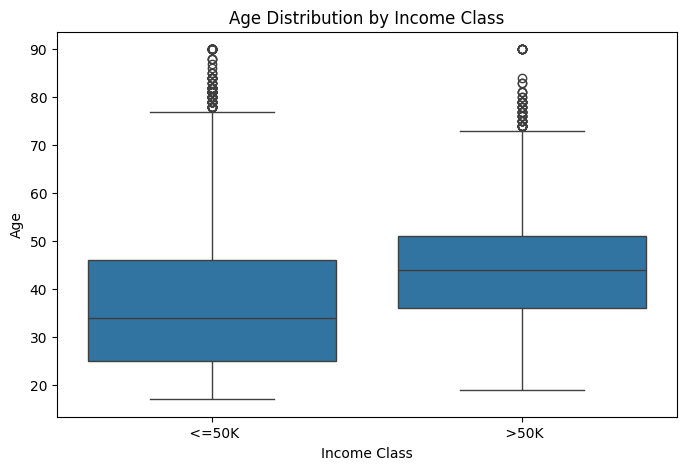

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Label", y="Age")

plt.title("Age Distribution by Income Class")
plt.xlabel("Income Class")
plt.ylabel("Age")
plt.show()

## 5. Income vs Education

Education is an important feature to investigate because educational attainment may be associated with income level.

In [ ]:
education_income = pd.crosstab(
    df["Education"],
    df["Label"].str.strip(),
    normalize="index"
) * 100

education_income = education_income.sort_values(
    by=">50K",
    ascending=False
)

education_income

Label,<=50K,>50K
Education,,
Doctorate,25.907990,74.092010
Prof-school,26.562500,73.437500
Masters,44.341265,55.658735
Bachelors,58.516997,41.483003
Assoc-voc,73.878437,26.121563
Assoc-acdm,75.164011,24.835989
Some-college,80.976546,19.023454
HS-grad,84.049138,15.950862
12th,92.378753,7.621247


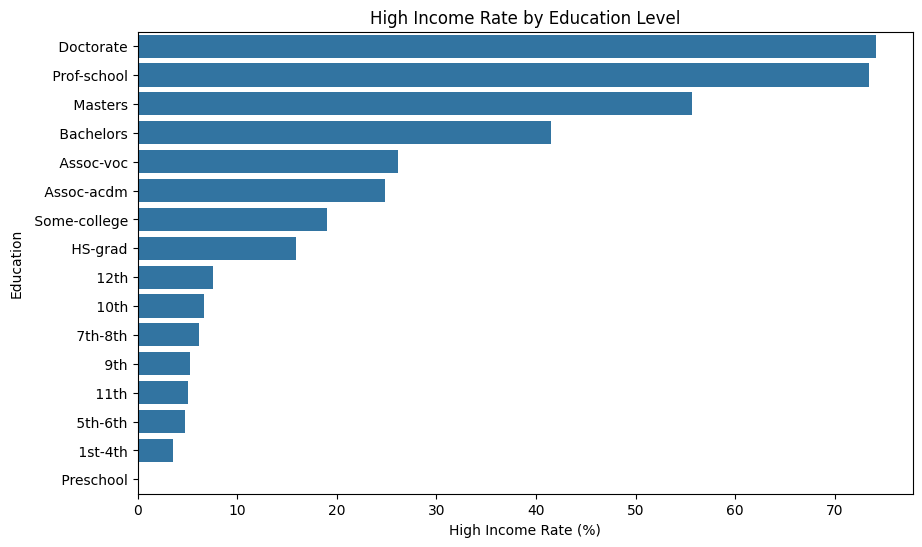

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=education_income[">50K"],
    y=education_income.index
)

plt.title("High Income Rate by Education Level")
plt.xlabel("High Income Rate (%)")
plt.ylabel("Education")
plt.show()

### Insight

The high-income rate varies across education levels. Higher educational attainment generally shows a different income distribution compared with lower educational levels.

## 6. Income vs Occupation

Occupation is analyzed to identify differences in the proportion of individuals earning more than $50K.

In [ ]:
occupation_income = pd.crosstab(
    df["Occupation"],
    df["Label"].str.strip(),
    normalize="index"
) * 100

occupation_income = occupation_income.sort_values(
    by=">50K",
    ascending=False
)

occupation_income

Label,<=50K,>50K
Occupation,,
Exec-managerial,51.598623,48.401377
Prof-specialty,55.096618,44.903382
Protective-serv,67.488444,32.511556
Tech-support,69.504310,30.495690
Sales,73.068493,26.931507
Craft-repair,77.335936,22.664064
Transport-moving,79.962430,20.037570
Adm-clerical,86.548156,13.451844
Machine-op-inspct,87.512488,12.487512


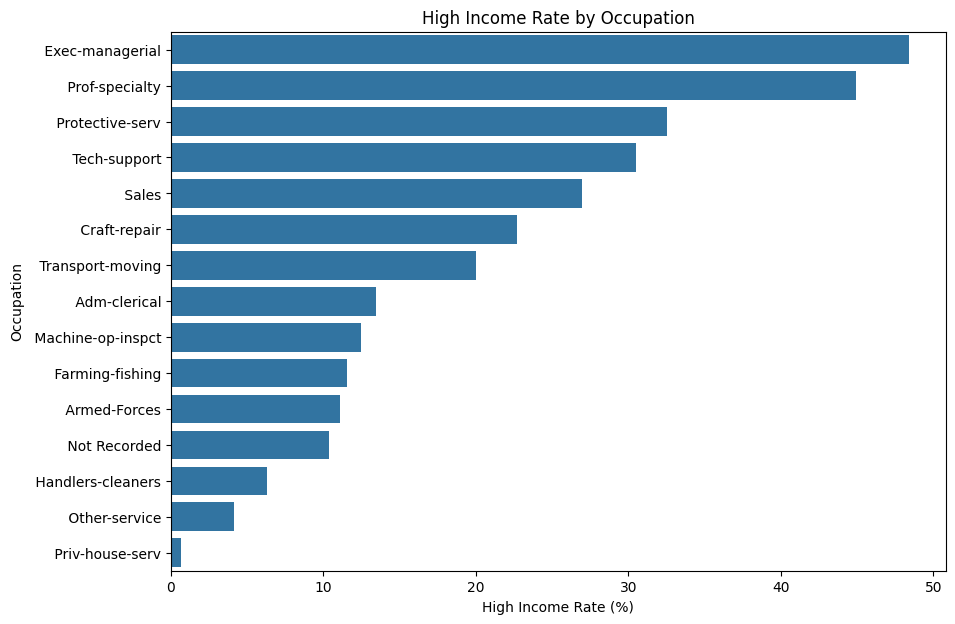

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=occupation_income[">50K"],
    y=occupation_income.index
)

plt.title("High Income Rate by Occupation")
plt.xlabel("High Income Rate (%)")
plt.ylabel("Occupation")
plt.show()

### Insight

The proportion of high-income individuals differs considerably across occupations, suggesting that occupation is an important feature to consider for income classification.

## 7. Income vs Working Hours

Working hours are examined to see whether people working longer hours have a different income distribution.

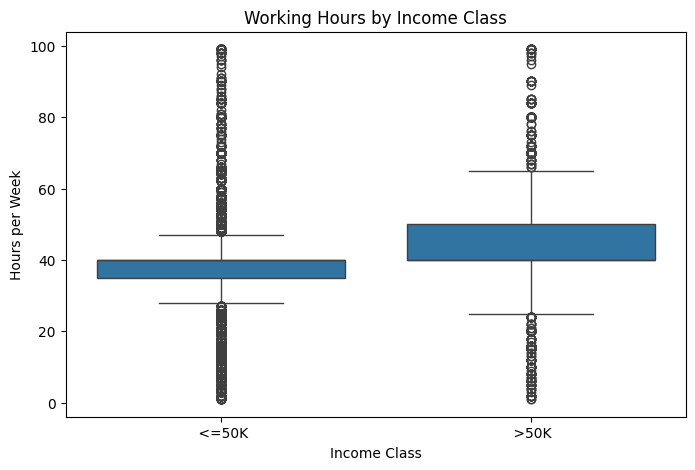

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Label", y="HoursPerWeek")

plt.title("Working Hours by Income Class")
plt.xlabel("Income Class")
plt.ylabel("Hours per Week")
plt.show()

## 8. Income vs Gender

We examine the income distribution across the two sex categories in the dataset.

In [ ]:
sex_income = pd.crosstab(
    df["Sex"],
    df["Label"],
    normalize="index"
) * 100

sex_income

Label,<=50K,>50K
Sex,,
Female,89.053941,10.946059
Male,69.424939,30.575061


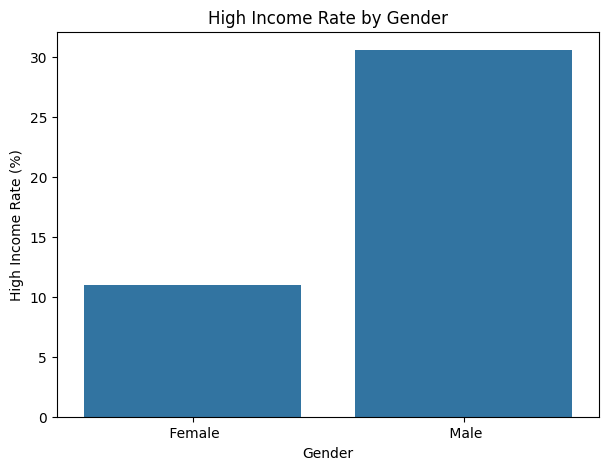

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=sex_income.reset_index(),
    x="Sex",
    y=" >50K"
)

plt.title("High Income Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("High Income Rate (%)")
plt.show()

## 9. Correlation Analysis

Correlation is examined for the numerical variables to identify basic relationships between them.

Correlation does not imply causation; it only describes the strength and direction of linear relationships between numerical variables.

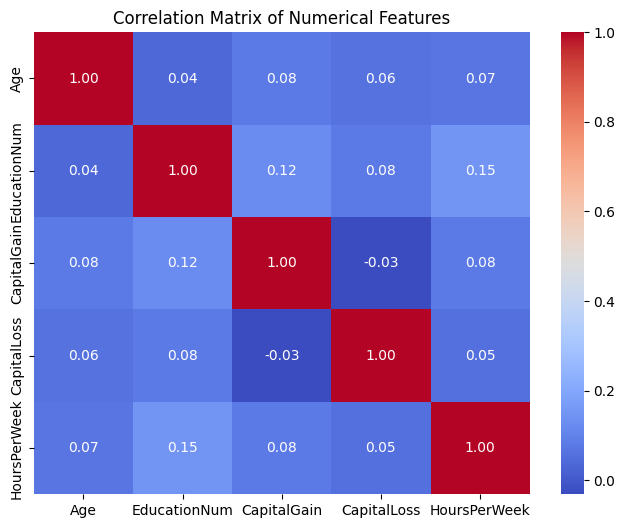

In [ ]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 10. EDA Summary

The EDA revealed several important patterns:

- The dataset contains two income classes: `<=50K` and `>50K`.
- The income classes are imbalanced, with the `<=50K` class representing the majority.
- Age and working hours show different distributions across income classes.
- Education level is associated with differences in the high-income rate.
- Occupation shows noticeable differences in high-income rates.
- Sex also shows differences in the income distribution.
- Numerical features have different scales and distributions, which should be considered during machine learning preprocessing.

These observations will be used as a starting point for the machine learning stage.

## Conclusion

The EDA provides an initial understanding of the factors associated with income level in the dataset.

The next stage is to prepare the features for machine learning and build a Logistic Regression classification model to predict whether an individual belongs to the `>50K` income class.